# Per-Run vs Combined-Run Category Decoding

`run_decoding.py` decodes stimulus category (face / figure / hand / house, chance = 25%)
by pooling trials from all 3 runs/sessions (`learning1`, `learning2`, `test`) and
cross-validating with `LeaveOneGroupOut` over runs (~328 trials total, train on 2
runs / test on the held-out run). This notebook asks how much that pooling buys us:
`run_perrun_decoding.py` reproduces that scheme unchanged as the `combined_logo`
baseline, and additionally decodes stimulus category *within* each single run in
isolation (~96-136 trials/run, no cross-run generalization at all), using a
repeated `StratifiedKFold` (5 folds x 10 repeats, averaged) since a single run has
no natural leave-one-X-out grouping and far fewer trials/category than the pooled set.

Same standardized decoder throughout: type-D GLMsingle betas, `NiftiMasker(standardize=True)`,
`LinearSVC(max_iter=10000, dual='auto')`, whole-brain + visual-cortex ROI (Harvard-Oxford atlas).

4 schemes compared: `combined_logo`, `run-learning1`, `run-learning2`, `run-test`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests

DATA_DIR = Path("/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample/bids_dataset/derivatives/perrun_decoding")
LABELS = ['face', 'figure', 'hand', 'house']
CHANCE = 1 / len(LABELS)

SCHEME_ORDER = ["combined_logo", "run-learning1", "run-learning2", "run-test"]
SCHEME_LABELS = {
    "combined_logo": "combined\n(LOGO, 3 folds)",
    "run-learning1": "learning1\n(5-fold x10 reps)",
    "run-learning2": "learning2\n(5-fold x10 reps)",
    "run-test":      "test\n(5-fold x10 reps)",
}
MASKS = ["wholebrain", "visualcortex"]
MASK_LABELS = {"wholebrain": "Whole brain", "visualcortex": "Visual cortex"}
MASK_COLORS = {"wholebrain": "#5B9BD5", "visualcortex": "#ED7D31"}

In [2]:
# Load per-subject accuracy CSVs (long format: mask, scheme, accuracy) and
# per-(mask, scheme) confusion matrices.
records = []
cms = {(m, s): [] for m in MASKS for s in SCHEME_ORDER}

for sub_dir in sorted(DATA_DIR.glob("sub-*")):
    sub_id = sub_dir.name.replace("sub-", "")
    acc_file = sub_dir / f"sub-{sub_id}_perrun_decoding_accuracy.csv"
    if not acc_file.exists():
        continue
    acc = pd.read_csv(acc_file)
    acc.insert(0, "subject", sub_id)
    records.append(acc)

    for mask in MASKS:
        for scheme in SCHEME_ORDER:
            cm_file = sub_dir / f"sub-{sub_id}_perrun_decoding_confusion_{mask}_{scheme}.npy"
            if cm_file.exists():
                cms[(mask, scheme)].append(np.load(cm_file))

df = pd.concat(records, ignore_index=True)
df["scheme"] = pd.Categorical(df["scheme"], categories=SCHEME_ORDER, ordered=True)
cms = {k: np.stack(v) for k, v in cms.items() if v}

n_sub = df["subject"].nunique()
print(f"{n_sub} subjects, masks: {MASKS}, schemes: {SCHEME_ORDER}")
df.head(8)

59 subjects, masks: ['wholebrain', 'visualcortex'], schemes: ['combined_logo', 'run-learning1', 'run-learning2', 'run-test']


,subject,mask,scheme,accuracy
0,01,wholebrain,combined_logo,0.338415
1,01,wholebrain,run-learning1,0.264583
2,01,wholebrain,run-learning2,0.286458
3,01,wholebrain,run-test,0.351471
4,01,visualcortex,combined_logo,0.533537
5,01,visualcortex,run-learning1,0.465625
6,01,visualcortex,run-learning2,0.447917
7,01,visualcortex,run-test,0.547059


## Group accuracy by scheme

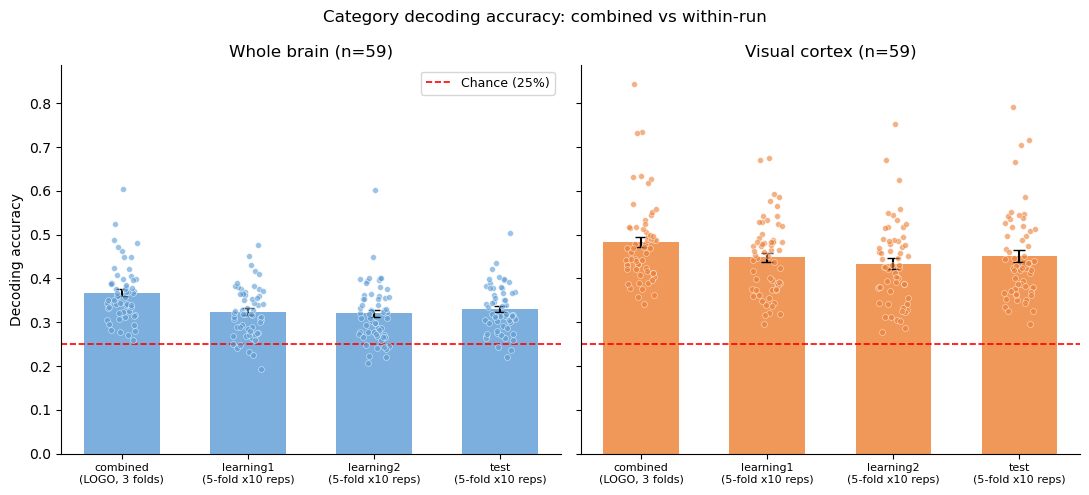

,mask,scheme,mean,sem,n
0,wholebrain,combined_logo,0.368024,0.008314,59
1,wholebrain,run-learning1,0.324541,0.007403,59
2,wholebrain,run-learning2,0.320145,0.008516,59
3,wholebrain,run-test,0.330733,0.006942,59
4,visualcortex,combined_logo,0.483309,0.012426,59
5,visualcortex,run-learning1,0.448129,0.011110,59
6,visualcortex,run-learning2,0.433581,0.012093,59
7,visualcortex,run-test,0.451084,0.013023,59


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
x = np.arange(len(SCHEME_ORDER))

summary_rows = []
for ax, mask in zip(axes, MASKS):
    color = MASK_COLORS[mask]
    wide = df[df["mask"] == mask].pivot_table(index="subject", columns="scheme",
                                               values="accuracy", observed=True)
    wide = wide.reindex(columns=SCHEME_ORDER)

    for i, scheme in enumerate(SCHEME_ORDER):
        vals = wide[scheme].dropna().values
        mean, sem = vals.mean(), vals.std() / np.sqrt(len(vals))
        summary_rows.append({"mask": mask, "scheme": scheme, "mean": mean, "sem": sem, "n": len(vals)})
        ax.bar(i, mean, width=0.6, color=color, alpha=0.8, zorder=2)
        ax.errorbar(i, mean, yerr=sem, fmt='none', color='black', capsize=4, linewidth=1.5, zorder=3)
        jitter = np.random.default_rng(0).uniform(-0.12, 0.12, len(vals))
        ax.scatter(i + jitter, vals, color=color, edgecolors='white',
                   linewidth=0.5, s=18, alpha=0.6, zorder=4)

    ax.axhline(CHANCE, color='red', linestyle='--', linewidth=1.2, label='Chance (25%)')
    ax.set_xticks(x)
    ax.set_xticklabels([SCHEME_LABELS[s] for s in SCHEME_ORDER], fontsize=8)
    ax.set_title(f"{MASK_LABELS[mask]} (n={wide.shape[0]})")
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel("Decoding accuracy")
axes[0].legend(fontsize=9)
plt.suptitle("Category decoding accuracy: combined vs within-run")
plt.tight_layout()
plt.show()

summary = pd.DataFrame(summary_rows)
summary

## Paired statistics

Two independent comparison families per mask, each Holm-corrected within its own
family of 3 comparisons (subject-paired, n=59):

- **Degradation** — does `combined_logo` outperform each single-run scheme? One-sided
  (`combined > run`), since more data + cross-run generalization should only help.
- **Run-to-run consistency** — do the 3 runs differ from each other? Two-sided, no
  directional prior a priori. `test` has the most trials of any single run (~136 vs
  ~96), so its degradation relative to `learning1`/`learning2` partly isolates a
  "more within-run data" effect from the "no cross-run generalization" effect shared
  by all three.

In [4]:
RUN_SCHEMES = ["run-learning1", "run-learning2", "run-test"]
RUN_PAIRS = [("run-learning1", "run-learning2"), ("run-learning1", "run-test"), ("run-learning2", "run-test")]

stats_rows = []
for mask in MASKS:
    wide = df[df["mask"] == mask].pivot_table(index="subject", columns="scheme",
                                               values="accuracy", observed=True)

    # Family A: degradation, combined_logo vs each run scheme, one-sided
    pt, pw = [], []
    for scheme in RUN_SCHEMES:
        t = stats.ttest_rel(wide["combined_logo"], wide[scheme], alternative="greater")
        w = stats.wilcoxon(wide["combined_logo"], wide[scheme], alternative="greater")
        pt.append(t.pvalue); pw.append(w.pvalue)
    _, pt_adj, _, _ = multipletests(pt, method="holm")
    _, pw_adj, _, _ = multipletests(pw, method="holm")
    for scheme, p_t, p_w, p_t_adj, p_w_adj in zip(RUN_SCHEMES, pt, pw, pt_adj, pw_adj):
        stats_rows.append({"mask": mask, "family": "degradation", "comparison": f"combined_logo > {scheme}",
                           "delta": wide["combined_logo"].mean() - wide[scheme].mean(),
                           "p_ttest": p_t, "p_ttest_holm": p_t_adj,
                           "p_wilcoxon": p_w, "p_wilcoxon_holm": p_w_adj})

    # Family B: run-to-run consistency, two-sided
    pt, pw = [], []
    for a, b in RUN_PAIRS:
        t = stats.ttest_rel(wide[a], wide[b], alternative="two-sided")
        w = stats.wilcoxon(wide[a], wide[b], alternative="two-sided")
        pt.append(t.pvalue); pw.append(w.pvalue)
    _, pt_adj, _, _ = multipletests(pt, method="holm")
    _, pw_adj, _, _ = multipletests(pw, method="holm")
    for (a, b), p_t, p_w, p_t_adj, p_w_adj in zip(RUN_PAIRS, pt, pw, pt_adj, pw_adj):
        stats_rows.append({"mask": mask, "family": "run-to-run", "comparison": f"{a} vs {b}",
                           "delta": wide[a].mean() - wide[b].mean(),
                           "p_ttest": p_t, "p_ttest_holm": p_t_adj,
                           "p_wilcoxon": p_w, "p_wilcoxon_holm": p_w_adj})

stats_df = pd.DataFrame(stats_rows)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
stats_df

,mask,family,comparison,delta,p_ttest,p_ttest_holm,p_wilcoxon,p_wilcoxon_holm
0,wholebrain,degradation,combined_logo > run-learning1,0.0435,0.0000,0.0000,0.0000,0.0000
1,wholebrain,degradation,combined_logo > run-learning2,0.0479,0.0000,0.0000,0.0000,0.0000
2,wholebrain,degradation,combined_logo > run-test,0.0373,0.0000,0.0000,0.0000,0.0000
3,wholebrain,run-to-run,run-learning1 vs run-learning2,0.0044,0.6289,1.0000,0.8103,0.9098
4,wholebrain,run-to-run,run-learning1 vs run-test,-0.0062,0.5308,1.0000,0.4549,0.9098
5,wholebrain,run-to-run,run-learning2 vs run-test,-0.0106,0.2973,0.8920,0.2576,0.7727
6,visualcortex,degradation,combined_logo > run-learning1,0.0352,0.0005,0.0005,0.0003,0.0003
7,visualcortex,degradation,combined_logo > run-learning2,0.0497,0.0000,0.0000,0.0000,0.0000
8,visualcortex,degradation,combined_logo > run-test,0.0322,0.0000,0.0000,0.0000,0.0000
9,visualcortex,run-to-run,run-learning1 vs run-learning2,0.0145,0.1984,0.3969,0.3671,0.7341


## Per-subject trajectories across schemes

Violin distribution per scheme with faint per-subject connecting lines
(`combined_logo -> learning1 -> learning2 -> test`) overlaid — the lines show
both the combined-vs-within-run degradation and the run-to-run consistency in
one panel per mask.

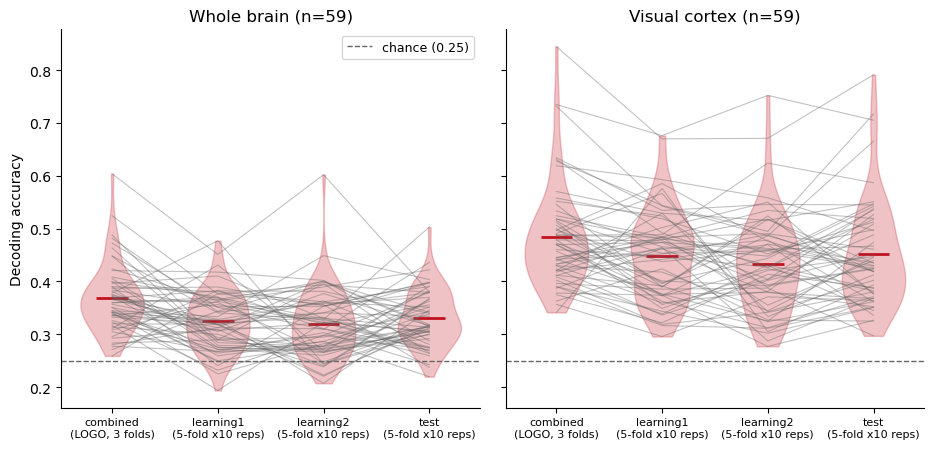

In [5]:
x = np.arange(len(SCHEME_ORDER))
ACCENT = "#c1121f"

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.6), sharey=True)
for ax, mask in zip(axes, MASKS):
    wide = df[df["mask"] == mask].pivot_table(index="subject", columns="scheme",
                                               values="accuracy", observed=True)
    wide = wide.reindex(columns=SCHEME_ORDER)

    violin_data = [wide[s].dropna().values for s in SCHEME_ORDER]
    parts = ax.violinplot(violin_data, positions=x, widths=0.6, showmeans=True, showextrema=False)
    for body in parts['bodies']:
        body.set_facecolor(ACCENT)
        body.set_edgecolor(ACCENT)
        body.set_alpha(0.25)
    parts['cmeans'].set_color(ACCENT)
    parts['cmeans'].set_linewidth(2)

    for _, row in wide.iterrows():
        ax.plot(x, row.values, color="0.4", lw=0.8, alpha=0.4, zorder=3)

    ax.axhline(CHANCE, ls="--", color="0.4", lw=1, label="chance (0.25)")
    ax.set_xticks(x)
    ax.set_xticklabels([SCHEME_LABELS[s] for s in SCHEME_ORDER], fontsize=8)
    ax.set_title(f"{MASK_LABELS[mask]} (n={wide.shape[0]})")
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel("Decoding accuracy")
axes[0].legend(fontsize=9)
plt.tight_layout()
plt.show()

## Confusion matrices (group average, normalized by true class)

One grid per mask: rows = scheme, columns = predicted category.

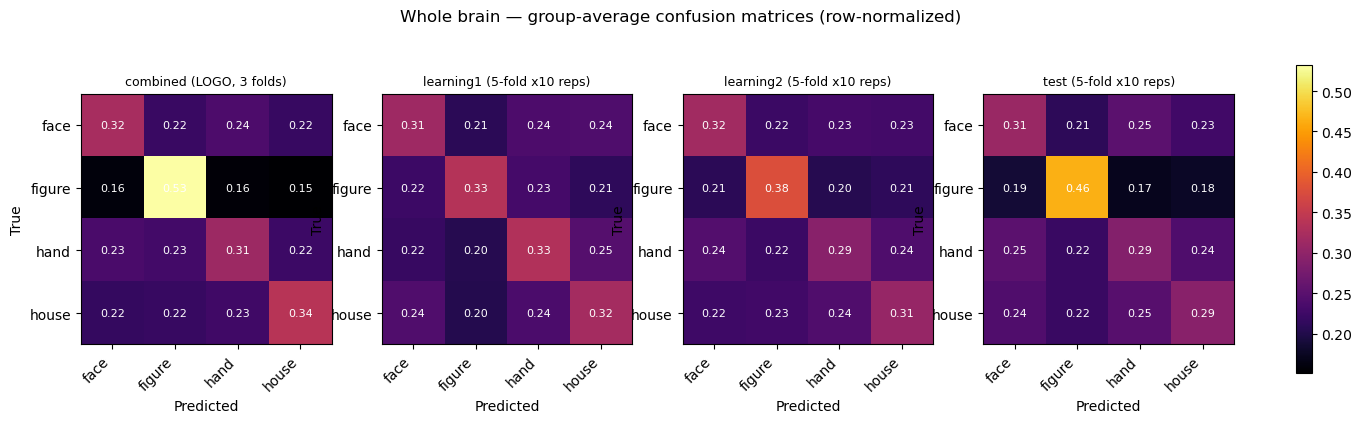

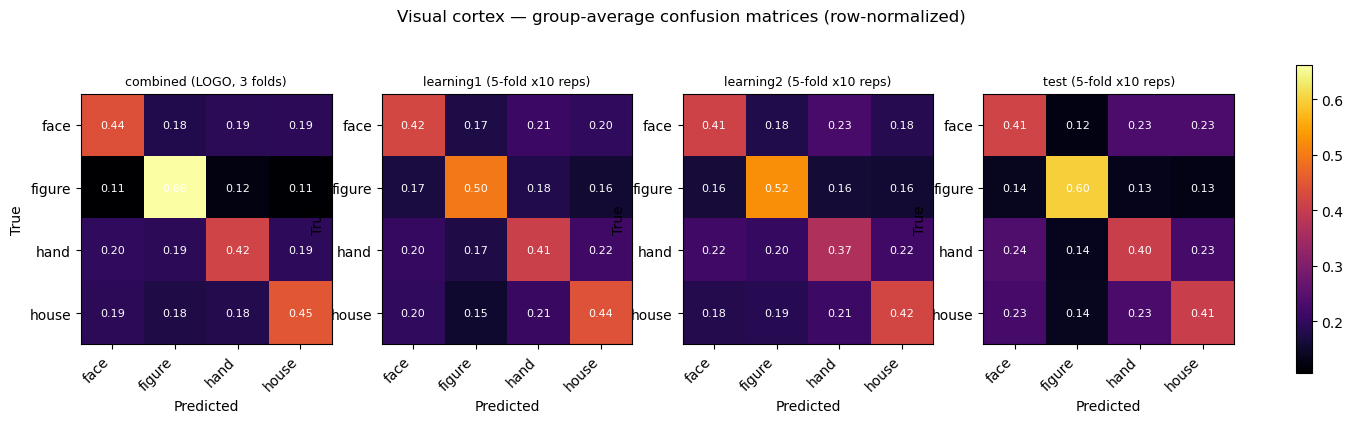

In [6]:
def normalize_cm(cm_stack):
    """Row-normalize each subject's CM, then average across subjects."""
    normed = cm_stack.astype(float)
    normed = normed / normed.sum(axis=2, keepdims=True)
    return normed.mean(axis=0)

for mask in MASKS:
    fig, axes = plt.subplots(1, len(SCHEME_ORDER), figsize=(4 * len(SCHEME_ORDER), 4))
    normed_all = [normalize_cm(cms[(mask, s)]) for s in SCHEME_ORDER]
    vmin = min(cm.min() for cm in normed_all)
    vmax = max(cm.max() for cm in normed_all)

    for ax, scheme, cm_norm in zip(axes, SCHEME_ORDER, normed_all):
        im = ax.imshow(cm_norm, cmap='inferno', vmin=vmin, vmax=vmax)
        ax.set_xticks(range(4)); ax.set_yticks(range(4))
        ax.set_xticklabels(LABELS, rotation=45, ha='right')
        ax.set_yticklabels(LABELS)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_title(SCHEME_LABELS[scheme].replace("\n", " "), fontsize=9)
        for r in range(4):
            for c in range(4):
                ax.text(c, r, f"{cm_norm[r, c]:.2f}",
                        ha='center', va='center', fontsize=8, color='white')
    fig.colorbar(im, ax=axes, fraction=0.02)
    plt.suptitle(f"{MASK_LABELS[mask]} — group-average confusion matrices (row-normalized)", y=1.02)
    plt.show()

## Verdict

All 59 subjects, whole-brain + visual-cortex, executed 2026-08-07 (cluster job 4392602).

| mask | combined mean | learning1 mean | learning2 mean | test mean | largest Δ (combined − run) | Holm-corrected p |
|---|---|---|---|---|---|---|
| whole-brain | 0.368 | 0.325 | 0.320 | 0.331 | **0.048** (vs learning2) | 6.5e-6 |
| visual-cortex | 0.483 | 0.448 | 0.434 | 0.451 | **0.050** (vs learning2) | 4.3e-6 |

**Clear, significant degradation, but not a sample-size story.** `combined_logo`
beats every single-run scheme in both masks, all three Holm-corrected (p < 0.001,
most p < 1e-4) — pooling all 3 runs and cross-validating between them clearly buys
real decoding power over decoding any one run in isolation. But the **run-to-run
comparisons are all non-significant** (Holm p > 0.29 whole-brain, p > 0.34
visual-cortex) — `run-test`, which has the most trials of any single run (~136 vs
~96), is *not* reliably more decodable than `learning1`/`learning2` despite the
~40% larger sample. If the degradation were mainly a sample-size effect, `test`
should stand out; it doesn't. This points to the loss of **cross-run
generalization** (the LOGO scheme's train-on-2-runs/test-on-held-out-run structure)
as the dominant driver, not simply having fewer trials to fit on — consistent with
some of the decodable signal being shared/stable structure across sessions that a
single-run model can't leverage, plus (partially) genuine day-to-day/session
non-stationarity that a single-session decoder overfits to.